# Test Lensing models

In [1]:
# including packages
using LazyGrids, PyPlot
using PSFModels

In [2]:
using Jens:LensBase as LB
using Jens:LensUtils as LU
using Jens:LensFITS as LF
using Jens:LensGenerator as LG

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.


# Lens instance

In [3]:
image_para = Dict(
    :num => 50,
    :deltap => 0.09,
    :redshift => 1.0,
    :bkg_noise => 0.5,
    :exp_time => 90,
)

Dict{Symbol, Real} with 5 entries:
  :num       => 50
  :deltap    => 0.09
  :bkg_noise => 0.5
  :redshift  => 1.0
  :exp_time  => 90

In [4]:
x = range(-5, 5, 101)
xg, yg = LazyGrids.ndgrid(x,x)

([-5.0 -5.0 … -5.0 -5.0; -4.9 -4.9 … -4.9 -4.9; … ; 4.9 4.9 … 4.9 4.9; 5.0 5.0 … 5.0 5.0], [-5.0 -4.9 … 4.9 5.0; -5.0 -4.9 … 4.9 5.0; … ; -5.0 -4.9 … 4.9 5.0; -5.0 -4.9 … 4.9 5.0])

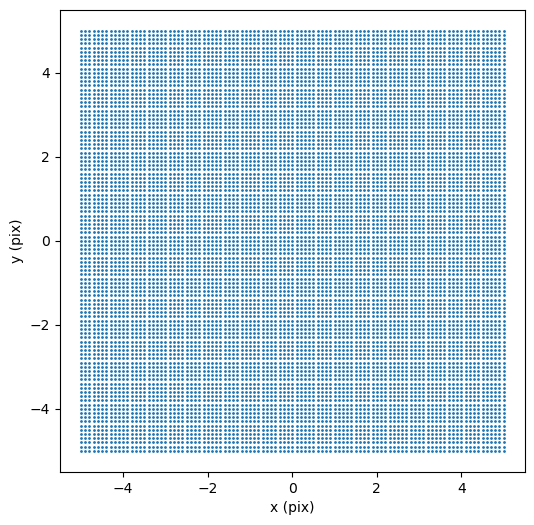

In [232]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(xg, yg, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# SIS

In [233]:
using Jens.LensModel:SIS as SIS

In [234]:
LensParaDict = Dict(:theta_E=>1., :xcentre => 0.1, :ycentre => .2);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIS, LensKwargs=LensParaDict)

([-4.299791333107531 -4.292893218813452 … -4.264644004071198 -4.271800007307197; -4.206891283748216 -4.199928589073943 … -4.171372331097993 -4.178612678969049; … ; 4.221719897266935 4.21463530099501 … 4.185489573506506 4.1928932188134524; 4.314198853502906 4.307173905802272 … 4.27831842547364 4.2856414186248815], [-4.286061751403757 -4.1928932188134524 … 4.222318984144045 4.314635300995009; -4.279166935098144 -4.185927160855422 … 4.215089991232113 4.307468171810287; … ; -4.265196555372512 -4.171800007307198 … 4.2003752073917875 4.292893218813453; -4.272211028207165 -4.178895289712568 … 4.207774816270635 4.300220165183557])

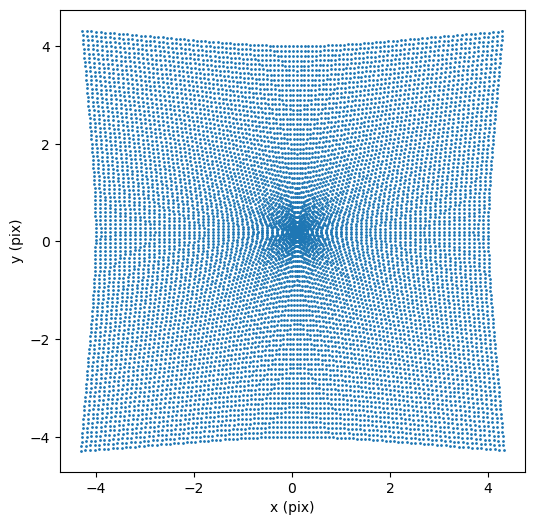

In [235]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Shear

In [236]:
using Jens.LensModel:Shear as Shear

In [237]:
LensParaDict = Dict(:gamma1=>0.1, :gamma2=>0.1,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=Shear, LensKwargs=LensParaDict)

([-3.99 -4.0 … -4.98 -4.99; -3.9000000000000004 -3.91 … -4.890000000000001 -4.9; … ; 4.92 4.91 … 3.93 3.9200000000000004; 5.01 5.0 … 4.02 4.01], [-4.99 -4.880000000000001 … 5.9 6.01; -5.0 -4.890000000000001 … 5.890000000000001 6.0; … ; -5.98 -5.870000000000001 … 4.91 5.02; -5.99 -5.880000000000001 … 4.9 5.01])

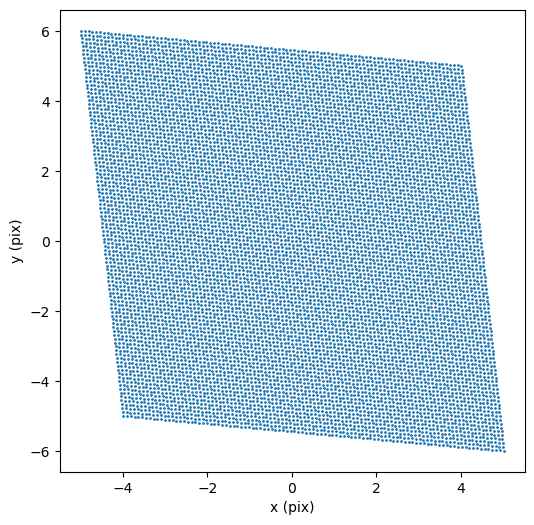

In [238]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Major-axes NIE model

In [239]:
using Jens.LensModel:NIEkappa as NIEkappa

In [249]:
# NIE model 
LensParaDict = Dict(:b => 1.5, :s => 0.1,
 :q => 0.4, :varphi =>  - pi/6. ,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIEkappa, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.4084429312700584 -3.3978409984042632 … -3.889364210238933 -3.9120760386372533; -3.3192128330532733 -3.3085271570906194 … -3.811922232320483 -3.8346519128492336; … ; 3.88117451145366 3.858461101944717 … 3.3308099902428974 3.341653294184969; 3.957684410395121 3.934954008254963 … 3.419513832272912 3.4302800807040947], [-3.0456637687517105 -2.956881465714677 … 3.2738536673550587 3.350155220102071; -3.035081687818215 -2.9461756994943515 … 3.2509141964693833 3.3276504915773994; … ; -3.282656178148457 -3.2049981866926123 … 2.9245112147950962 3.013683928397703; -3.305145082315224 -3.2279564837411727 … 2.935384526309207 3.024420603551887])

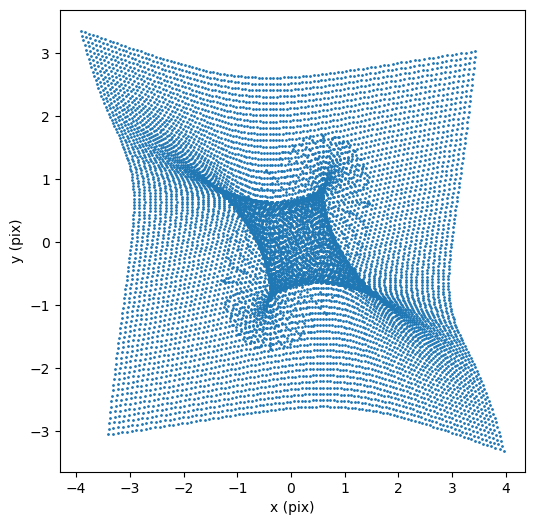

In [250]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

In [251]:
PyPlot.clf()

In [252]:
# NIE model 
LensParaDict1 = Dict(:b => 0.6, :s => 0.1,
 :q => 0.2, :varphi =>  - pi/3. ,
  :xcentre => -1.5, :ycentre => 1.);
alphax1, alphay1 =  NIEkappa.LensDerivative(xg, yg; LensParaDict1...)
# NIE model 
LensParaDict2 = Dict(:b => 0.6, :s => 0.1,
 :q => 0.2, :varphi =>  pi/6. ,
  :xcentre => 2, :ycentre => -1);
alphax2, alphay2 =  NIEkappa.LensDerivative(xg, yg; LensParaDict2...)
betax2 = xg .- alphax1 .- alphax2;
betay2 = yg .- alphay1 .- alphay2;

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

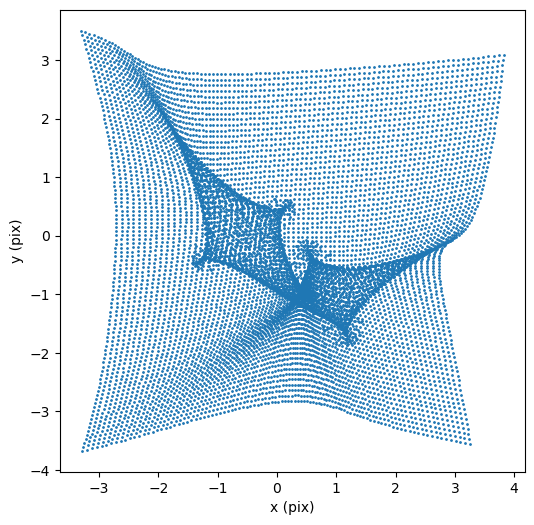

In [253]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax2, betay2, s=1, )
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NIE model

In [254]:
using Jens.LensModel:NIE as NIE

In [257]:
# NIE model 
LensParaDict = Dict(:theta_E => 2., :s_scale => 0.1,
 :e1 => 0.2, :e2 =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NIE, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-4.0080420711121745 -3.9902708799997453 … -3.6598332423423923 -3.6694001979032276; -3.9259549946618653 -3.908135598600845 … -3.569653380734747 -3.579292986310315; … ; 3.599892393982574 3.5901168419465326 … 3.9450975429395045 3.9629768916921497; 3.6894545288510483 3.679745286280731 … 4.026409742593342 4.0442653894006195], [-3.5901411134737855 -3.508901598657034 … 3.28418943596343 3.373888376150993; -3.5724956057015893 -3.490954901948052 … 3.274530510977229 3.3643405093661096; … ; -3.3450430598344827 -3.254993592789999 … 3.454926357800522 3.5371101048473754; -3.3547243276821925 -3.2647975278973185 … 3.472959047653689 3.5548145444587274])

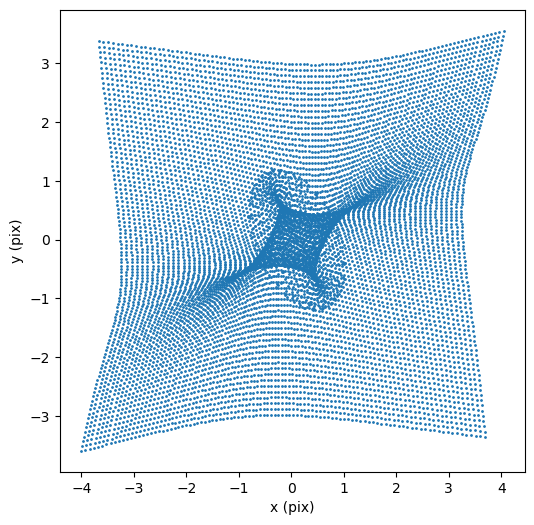

In [258]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Point mass

In [259]:
using Jens.LensModel:PointMass as PointMass

In [260]:
LensParaDict = Dict(:theta_E => 0.3, :xcentre => 0., :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=PointMass, LensKwargs=LensParaDict)

([-4.991 -4.990818200367272 … -4.990818200367272 -4.991; -4.891001836359927 -4.890816326530612 … -4.890816326530612 -4.891001836359927; … ; 4.891001836359927 4.890816326530612 … 4.890816326530612 4.891001836359927; 4.991 4.990818200367272 … 4.990818200367272 4.991], [-4.991 -4.891001836359927 … 4.891001836359927 4.991; -4.990818200367272 -4.890816326530612 … 4.890816326530612 4.990818200367272; … ; -4.990818200367272 -4.890816326530612 … 4.890816326530612 4.990818200367272; -4.991 -4.891001836359927 … 4.891001836359927 4.991])

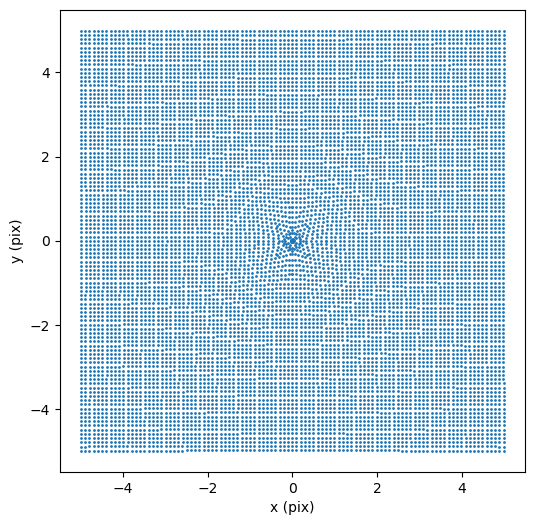

In [261]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# SIE model

In [262]:
using Jens.LensModel:SIE as SIE

In [265]:
LensParaDict = Dict(:b => 2., :s => 0.01,
 :q => 0.6, :varphi =>  0.3,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=SIE, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()Matrix{Float64}(101, 101)Float64()

([-3.5389621445648984 -3.518941405901267 … -3.3174372463710924 -3.332627731496515; -3.458730585478888 -3.4386045260841533 … -3.2323657060018354 -3.2476684492746783; … ; 3.2789902074543336 3.263479312806858 … 3.4794522331784625 3.4997583484590775; 3.3631189171871965 3.347709194977056 … 3.558771338820116 3.5789927671425366], [-3.0376175729535673 -2.9582857825863247 … 2.8207297990438844 2.905038577911608; -3.0176921993921137 -2.9380631449734187 … 2.805386600235077 2.8898880560354243; … ; -2.8592781832442125 -2.77436194520763 … 2.8973055951533535 2.977571556578584; -2.8746327132370766 -2.789928834850549 … 2.9177329962348213 2.9976734060143566])

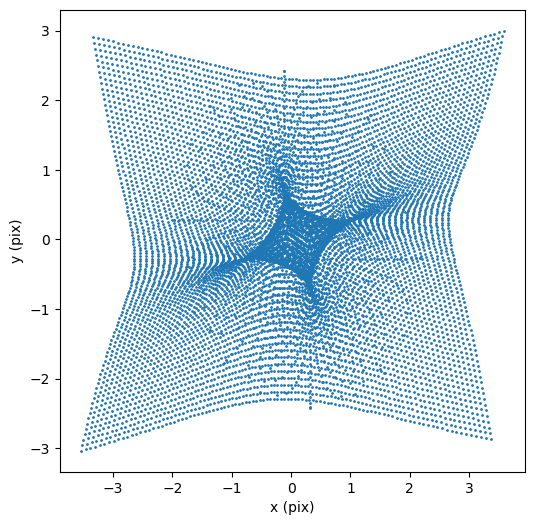

In [266]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# EPL model

In [267]:
using Jens.LensModel:EPL as EPL

In [270]:
LensParaDict = Dict(:theta_E => 1., :gamma => 0.1,
:e1 => 0.1, :e2 =>  0.2,
  :xcentre => 0.1, :ycentre => .1);
betax, betay = LB.LensPlane(xg, yg; LensModel=EPL, LensKwargs=LensParaDict)

Matrix{Float64}(101, 101)Float64()

([19.45520282384194 19.009620990064796 … 0.5601712043943543 0.34992657528593174; 19.097608492650423 18.652170830466282 … 0.26056330490658386 0.049448934537378975; … ; 1.1737145075534317 0.9507549523553829 … -16.89446865686415 -17.323993964565936; 0.8836127576101385 0.6617214309012924 … -17.2355785014991 -17.665248581012637], [2.3518793663420716 1.8361407346431617 … -57.63505374073716 -58.87953697810125; 2.697644393096283 2.1804041172072397 … -56.568624182501054 -57.805105584003904; … ; 58.38114225471757 57.127531663455855 … -1.6519924562873092 -2.147221032541207; 59.448699002174834 58.187117753767794 … -1.320051009556452 -1.813771882247778])

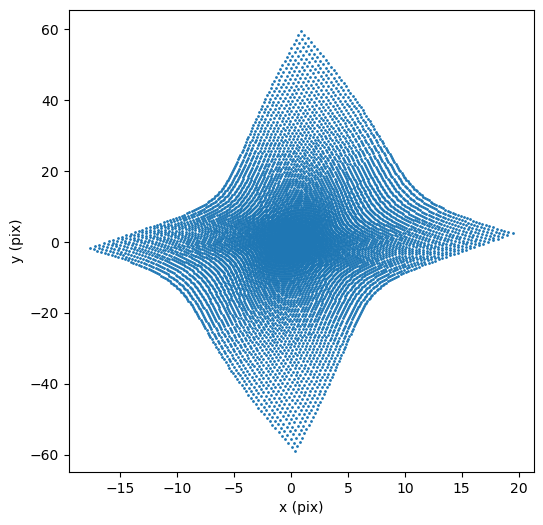

In [271]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NFW (spherical)

In [5]:
using Jens.LensModel:NFW as NFW

In [12]:
LensParaDict = Dict(:Rs=>2.0, :alpha_Rs=>0.1,
  :xcentre => 0.1, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFW, LensKwargs=LensParaDict)

([-4.937759231695606 -4.936967961562963 … -4.936967961562963 -4.937759231695606; -4.8381879680548305 -4.837387649111367 … -4.837387649111367 -4.8381879680548305; … ; 4.83911579440421 4.838298148244667 … 4.838298148244667 4.83911579440421; 4.93863989612914 4.937830773739989 … 4.937830773739989 4.93863989612914], [-4.93897963891726 -4.839439806207553 … 4.839439806207553 4.93897963891726; -4.93818796805483 -4.83863989612914 … 4.83863989612914 4.93818796805483; … ; -4.936578952504385 -4.837012692999765 … 4.837012692999765 4.936578952504385; -4.937387649111367 -4.83783077373999 … 4.83783077373999 4.937387649111367])

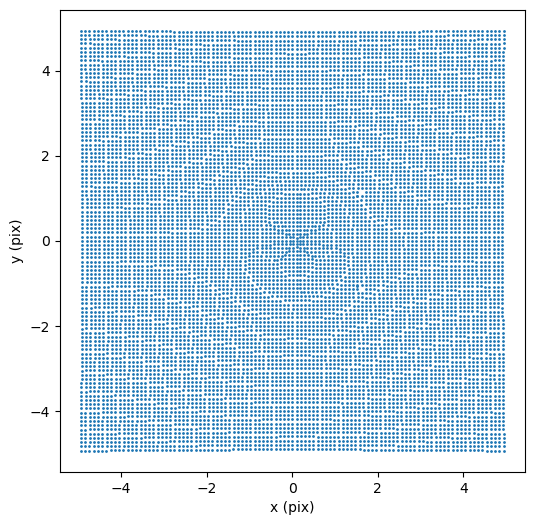

In [14]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# NFW (elliptical)

In [15]:
using Jens.LensModel:NFWE as NFWE

In [38]:
LensParaDict = Dict(:Rs=>1.5, :alpha_Rs=>1., :e1=>0.3, :e2=>0.2,
  :xcentre => 0.4, :ycentre => .0);
betax, betay = LB.LensPlane(xg, yg; LensModel=NFWE, LensKwargs=LensParaDict)

([-4.626308500891334 -4.614672313425321 … -4.617723464132997 -4.6234502221136005; -4.534615002945957 -4.523074426237519 … -4.520021974862563 -4.525746008438084; … ; 4.546659371567514 4.541026404332938 … 4.5945425805259 4.604994030859159; 4.643784193735064 4.638132372520408 … 4.685235383565237 4.695853816157457], [-4.271435998140657 -4.172005906435695 … 4.301689035250173 4.402877130464664; -4.266533437647971 -4.166859048835613 … 4.298030548662866 4.399286586792338; … ; -4.369946831228819 -4.268102169370572 … 4.1300220808648245 4.231612359447112; -4.373667942538904 -4.271901189446137 … 4.134166446620776 4.235524456828202])

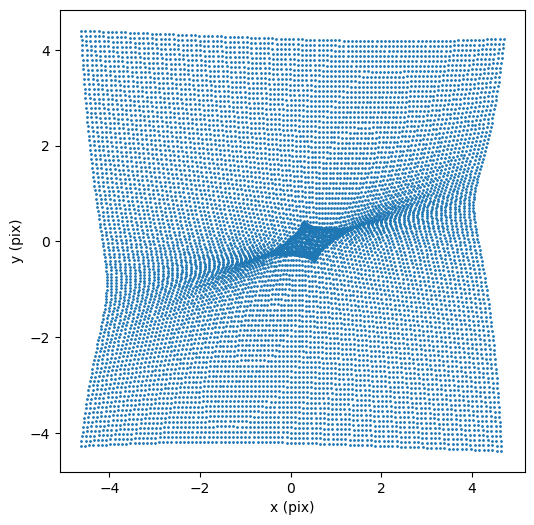

In [40]:
FigLnes = PyPlot.figure(figsize=(6, 6))
PyPlot.scatter(betax, betay, s=1)
PyPlot.xlabel("x (pix)")
PyPlot.ylabel("y (pix)")
gcf()

# Gaussian